## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer_bool = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"][which_dataset]

data_path = config["data_path"][which_dataset]
results_path = config["results_path"]
figures_path = config["figures_path"]
models_path = config["models_path"][which_dataset]

In [3]:
columns_to_keep_inds = [el + '_i' for el in elements_to_keep]
columns_to_keep_inks = [el + '_a' for el in elements_to_keep]

## Loading the data

In [4]:
df = pd.read_csv(data_path)
inks_df = df[[col for col in df.columns if col.endswith('_a')]]
inks_df.columns = [col.split('_')[0] for col in inks_df.columns]
inds_df = df[[col for col in df.columns if col.endswith('_i')]]
inds_df.columns = [col.split('_')[0] for col in inds_df.columns]

if which_dataset == 'old':
    df['sample_i'] = df['inds'].apply(lambda x: x.split('.')[0])
    df['sample_a'] = df['sample_i']
    df.rename(columns={'inds': 'name'}, inplace=True)

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inDKs_df = df

### Keeping track of the records from the same sample

Check

In [6]:
if which_dataset == 'old':
    all(inDKs_df['sample_i'] == inDKs_df['sample_a'])
if which_dataset == 'new':
    all(inDKs_df['name_i'].apply(lambda x: (x.split('_')[0]).split('.')[0]) == inDKs_df['name_a'].apply(lambda x: (x.split('_')[0]).split('.')[0]))

We can use adjusted 'name' column as sample id:

In [7]:
if which_dataset == 'old':
    inDKs_df['Sample_id'] = inDKs_df['sample_i']
if which_dataset == 'new':
    inDKs_df['Sample_id'] = inDKs_df['name_i'].apply(lambda x: (x.split('_')[0]).split('.')[0])
    inDKs_df['name'] = inDKs_df['Sample_id'] + '_' + inDKs_df['name_i'].apply(lambda x: x.split('_')[-1])

### Removing some data

1. Let's remove 'outer' samples:

In [8]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [9]:
if remove_outer_bool:
    inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks + columns_to_keep_inds + ['Sample_id', 'name'] ]

3. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.0

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [12]:
(inDKs_df[columns_to_keep_inks + columns_to_keep_inds]<0).sum().sum() == 0

np.True_

In [13]:
for col in columns_to_keep_inks + columns_to_keep_inds:
    inDKs_df[col][inDKs_df[col] < 0] = 0

/tmp/ipykernel_22536/1556174307.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  inDKs_df[col][inDKs_df[col] < 0] = 0
/tmp/ipykernel_22536/1556174307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

5. Let's multiply the values by weights.

In [14]:
if which_dataset == "new":
    
    #Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg
    custom_weights = [1, 1, 1, 10, 19, 20, 17, 9, 20, 1]
    weights = [el/sum(custom_weights) for el in custom_weights]
    
    for i, col in enumerate(columns_to_keep_inds):
        inDKs_df[col] = weights[i]*inDKs_df[col]
    for i, col in enumerate(columns_to_keep_inks):
        inDKs_df[col] = weights[i]*inDKs_df[col]

/tmp/ipykernel_22536/3900386952.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inDKs_df[col] = weights[i]*inDKs_df[col]
/tmp/ipykernel_22536/3900386952.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inDKs_df[col] = weights[i]*inDKs_df[col]


6. Normalize with respect to Fe and remove Fe.

In [15]:
# for i, col in enumerate(columns_to_keep_inks):
#     inDKs_df[col] = inDKs_df[col] / inDKs_df['Fe_a']

In [16]:
# for i, col in enumerate(columns_to_keep_inds):
#     inDKs_df[col] = inDKs_df[col] / inDKs_df['Fe_i']

In [17]:
# inDKs_df.drop(columns=['Fe_a', 'Fe_i'], inplace=True)
# columns_to_keep_inks.remove('Fe_a')
# columns_to_keep_inds.remove('Fe_i')

### Train test split, datasets, dataloaders

In [18]:
indices = list(range(int(inDKs_df.shape[0])))
ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

partition = {'train': ind_train_all,
         'val': ind_val_all,
        'test': ind_test_all}

X_y_train = inDKs_df.iloc[partition['train'],:]
X_y_val = inDKs_df.iloc[partition['val'],:]
X_y_test = inDKs_df.iloc[partition['test'],:]

X_y_train.reset_index(drop=True, inplace=True)
X_y_val.reset_index(drop=True, inplace=True)
X_y_test.reset_index(drop=True, inplace=True)

### Creating features and labels matrices

In [19]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

X_train = np.array(X_y_train[columns_to_keep_inds].values)
y_train = np.array(X_y_train[columns_to_keep_inks].values)
X_val = np.array(X_y_val[columns_to_keep_inds].values)
y_val = np.array(X_y_val[columns_to_keep_inks].values)
X_test = np.array(X_y_test[columns_to_keep_inds].values)
y_test = np.array(X_y_test[columns_to_keep_inks].values)

### Normalization / taking logarithm

In [20]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0.)
    return res

In [21]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

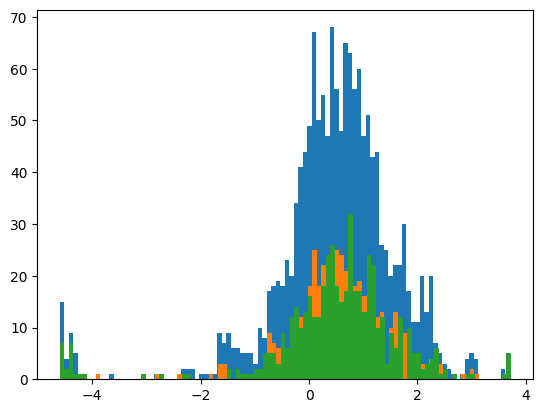

In [22]:
dim = 0
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);

#np.argwhere(X_train[:,2]<-20)

### Converting to tensors

In [23]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [24]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [25]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [26]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [27]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [28]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [29]:
dropout_prob = 0.1

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.Dropout(dropout_prob),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Linear(64, 256),
        nn.Dropout(dropout_prob),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 1024),
        nn.Dropout(dropout_prob),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Linear(1024, 256),
        nn.Dropout(dropout_prob),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 64),
        nn.Dropout(dropout_prob),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Linear(64, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [30]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Dropout(p=0.1, inplace=False)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): Dropout(p=0.1, inplace=False)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1024, bias=True)
    (9): Dropout(p=0.1, inplace=False)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=1024, out_features=256, bias=True)
    (13): Dropout(p=0.1, inplace=False)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=64, bias=True)
    (17): Dropout(p=0.1, inplace=False)
    (18): BatchNorm1d(64, eps=1e-05

In [31]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [32]:
weights = torch.tensor([1/input_size]*input_size).unsqueeze(1).to(device)
# custom_weights = [1, 1, 1, 10, 19, 20, 17, 9, 20, 1]
# weights = torch.tensor([el/sum(custom_weights) for el in custom_weights]).unsqueeze(1).to(device)
#Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg
#1, 1, 1, 10, 19, 20, 17, 9, 20, 1

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [33]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 4.57071917851766 test 4.470721218241266
EPOCH 2:
LOSS train 4.14505983988444 test 3.7033233211701173
EPOCH 3:
LOSS train 3.730494817097982 test 3.2684004515050407
EPOCH 4:
LOSS train 3.291513172785441 test 2.824275425160266
EPOCH 5:
LOSS train 2.829996681213379 test 2.3577652067305093
EPOCH 6:
LOSS train 2.389031505584717 test 1.9947787677667228
EPOCH 7:
LOSS train 1.9960744063059488 test 1.7097023419108257
EPOCH 8:
LOSS train 1.7055728912353516 test 1.437344769517102
EPOCH 9:
LOSS train 1.4963383992513022 test 1.3147853749344147
EPOCH 10:
LOSS train 1.3669448057810465 test 1.2565816524158042
EPOCH 11:
LOSS train 1.2544910033543906 test 1.1406865741115018
EPOCH 12:
LOSS train 1.147166951497396 test 1.0291675468644943
EPOCH 13:
LOSS train 1.0624886274337768 test 0.9215302426053817
EPOCH 14:
LOSS train 0.9776849627494812 test 0.8668387529241991
EPOCH 15:
LOSS train 0.8964573224385579 test 0.8022476166905649
EPOCH 16:
LOSS train 0.8375914931297302 test 0.74137603674068

In [33]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 4.566451994578044 test 4.543319338775543
EPOCH 2:
LOSS train 4.1770140647888185 test 3.722825119533692
EPOCH 3:
LOSS train 3.773966900507609 test 3.1875795532900644
EPOCH 4:
LOSS train 3.320435396830241 test 2.7811223086583086
EPOCH 5:
LOSS train 2.8475611050923666 test 2.6254383715759797
EPOCH 6:
LOSS train 2.3766698201497394 test 2.1608457795108658
EPOCH 7:
LOSS train 1.9701162576675415 test 2.007008620055325
EPOCH 8:
LOSS train 1.6540117820103963 test 1.8109951010908947
EPOCH 9:
LOSS train 1.4774025440216065 test 1.5804673067058426
EPOCH 10:
LOSS train 1.3346978425979614 test 1.396534129199254
EPOCH 11:
LOSS train 1.2432307720184326 test 1.3051173219000958
EPOCH 12:
LOSS train 1.1574480056762695 test 1.2801171870954544
EPOCH 13:
LOSS train 1.0671851833661397 test 1.1862794158449135
EPOCH 14:
LOSS train 1.0100026408831277 test 1.2189425567546524
EPOCH 15:
LOSS train 0.9704418500264486 test 1.0740663640829453
EPOCH 16:
LOSS train 0.94936044216156 test 1.02650807295

In [ ]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [45]:
#%matplotlib widget

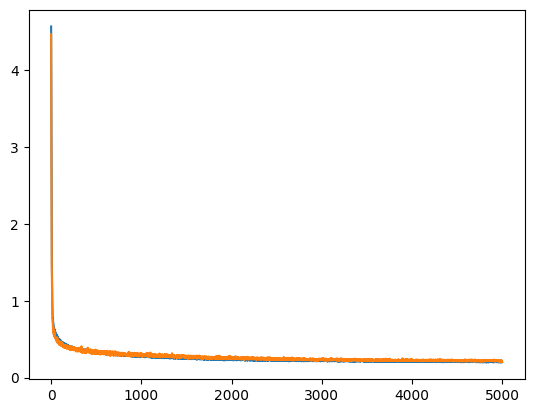

In [34]:
plt.plot(train_losses)
plt.plot(val_losses)

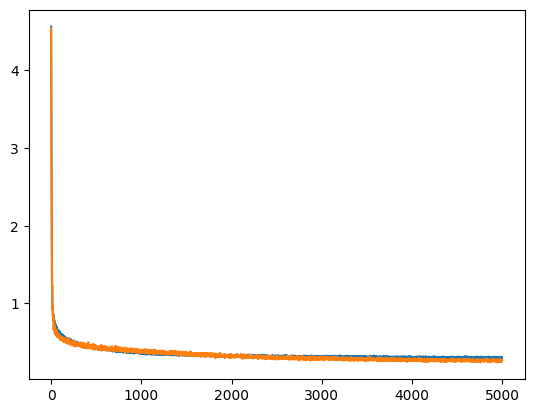

In [34]:
plt.plot(train_losses)
plt.plot(val_losses)

## Loading pretrained model

In [33]:
# model = InksNet().to(device)
# model.load_state_dict(torch.load(models_path))

/tmp/ipykernel_7530/12144023.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(models_path))


<All keys matched successfully>

## Prediction on test set

In [35]:
model.eval()
loss_fn = CustomLoss()

running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [36]:
lab

tensor([[ 3.8680,  2.0324, -1.8046,  ...,  4.8597, 11.1846,  4.9238],
        [ 4.6584,  2.3974, -0.9194,  ...,  7.1934, 11.0806,  4.6677],
        [ 3.1933,  2.0893, -2.3112,  ...,  4.2102, 10.7668,  4.2131],
        ...,
        [ 3.7895,  2.1499, -2.6429,  ...,  5.1586, 10.3751,  4.7508],
        [ 5.4275,  3.5121, -1.0072,  ...,  6.6777, 12.4322,  5.9789],
        [ 4.0341,  2.5511, -2.1872,  ...,  5.4481, 10.1772,  4.3534]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [37]:
out

tensor([[ 3.6408,  2.1631, -1.7982,  ...,  4.8085, 11.2371,  4.7656],
        [ 4.5595,  2.3560, -0.9571,  ...,  7.1602, 11.0215,  4.7227],
        [ 3.2905,  2.3947, -3.0946,  ...,  4.1251, 10.9164,  4.5920],
        ...,
        [ 3.8200,  2.2752, -1.4143,  ...,  5.2794, 10.3133,  4.6790],
        [ 5.3195,  3.5565, -0.8774,  ...,  6.6057, 12.3332,  6.0015],
        [ 4.1554,  1.8856, -2.5341,  ...,  5.3885, 10.2799,  4.6835]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [38]:
res

tensor([[0.2273, 0.1307, 0.0065,  ..., 0.0512, 0.0524, 0.1582],
        [0.0989, 0.0414, 0.0377,  ..., 0.0332, 0.0591, 0.0550],
        [0.0972, 0.3054, 0.7834,  ..., 0.0850, 0.1497, 0.3789],
        ...,
        [0.0305, 0.1253, 1.2286,  ..., 0.1209, 0.0618, 0.0718],
        [0.1080, 0.0445, 0.1298,  ..., 0.0720, 0.0990, 0.0227],
        [0.1214, 0.6655, 0.3470,  ..., 0.0596, 0.1027, 0.3302]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [39]:
torch.mean(res, axis=0)  # 10 elements, new data

tensor([0.1364, 0.1907, 0.3598, 0.1390, 0.2053, 0.1704, 0.2070, 0.1809, 0.1565,
        0.1520], device='cuda:0', grad_fn=<MeanBackward1>)

In [40]:
torch.mean(res, axis=0)  # 8 elements, old data

tensor([0.2338, 0.1530, 0.3298, 0.1149, 0.1917, 0.2002, 0.2166, 0.1863],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [40]:
torch.mean(res) # 10 elements, new data

tensor(0.1898, device='cuda:0', grad_fn=<MeanBackward0>)

In [41]:
torch.mean(res) # 8 elements, old data

tensor(0.2033, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [78]:
outer_removed = 'outer_removed' if remove_outer else 'outer_not_removed'

elements = '_'.join(elements_to_keep)
settings_str = '_' + preprocessing_method + '_' + \
                outer_removed + '_' + str(how_many_outer_to_remove) + \
                '_' + elements + '_'

import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), '/'.join(models_path.split('/')[:-1]) + '/model_regression' + settings_str + now)

### Visualisations

In [41]:
dim_nr = 9
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

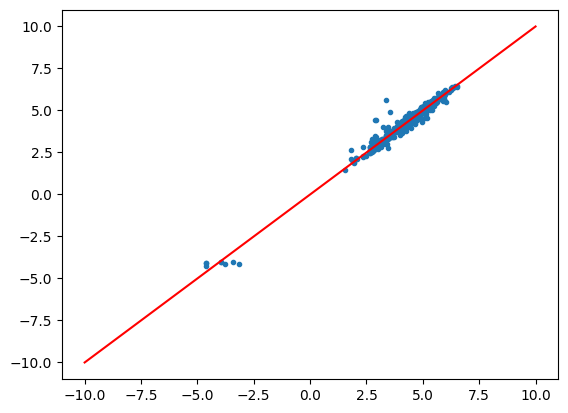

In [42]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [43]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [44]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [45]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)

mean_df['Sample_id'] = mean_df['Sample_id'].astype(str)
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_22536/1503384335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_22536/1503384335.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_22536/1503384335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [46]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [47]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [48]:
len(closest)

498

In [49]:
y_test_df['Closest'] = closest

In [50]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

481

In [51]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9658634538152611

#### Now let's check if it works for the neural network's output.

In [52]:
model.eval()
outputs = model(X_test)

In [53]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df['Real sample_id'] = outputs_df['Real sample_id'].astype(str)
outputs_df.reset_index(drop=True, inplace=True)

In [54]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [55]:
len(closest)

498

In [56]:
outputs_df['Closest'] = closest

In [57]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

449

In [57]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

429

In [58]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest) #new data

0.9016064257028112

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from seaborn import heatmap

In [60]:
acc = np.round(100*outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest), 1)
print('Accuracy: '+str(acc)+'%.') # new data

Accuracy: 90.2%.


In [61]:
normalization_in_conf_mat = None

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

tp_and_fn = conf_mat.sum(1)
tp_and_fp = conf_mat.sum(0)
tp = conf_mat.diagonal()

precision = tp / tp_and_fp
recall = tp / tp_and_fn

print('Precision: ' + str(np.nanmean(precision)))
print('Recall: ' + str(np.nanmean(recall)))

Precision: 0.9254805591961556
Recall: 0.9107142857142857


/tmp/ipykernel_22536/2917754103.py:10: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/tmp/ipykernel_22536/2917754103.py:11: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


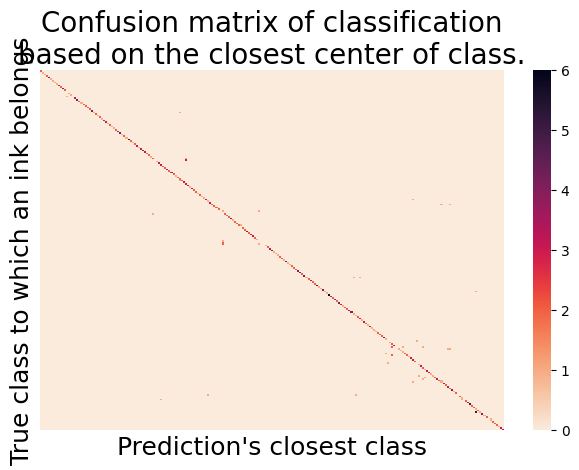

In [62]:
normalization_in_conf_mat = None
scores = {
            'pred': 'Precision',
            'true': 'Recall',
            None: 'Confusion matrix'
            }

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

heatmap(conf_mat, cmap=sns.cm.rocket_r, xticklabels=False, yticklabels=False)
plt.ylabel('True class to which an ink belongs', size=18)
plt.xlabel("Prediction's closest class", size=18)
plt.rcParams['figure.figsize'] = [15, 10]
plt.title(scores[normalization_in_conf_mat] + ' of classification based on the closest center of class.', 
          size=20, 
          wrap=True)

plt.tight_layout()
#plt.savefig('../figures/heatmap_' + scores[normalization_in_conf_mat] + '.png')

## Quality of prediction: confidence intervals

In [63]:
model.eval()
outputs = model(X_test)

In [64]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [65]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [66]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_22536/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_22536/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_22536/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [67]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_22536/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_22536/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_22536/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [68]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [69]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

Percentage of points inside mean +- 2 standard deviations interval:

In [70]:
np.array(sd_res_list).mean()

np.float64(0.8453815261044176)

On consecutive coordinates:

In [71]:
np.array(sd_res_list).mean(0)

array([[0.82730924, 0.86947791, 0.91967871, 0.85542169, 0.85341365,
        0.79116466, 0.84337349, 0.82329317, 0.8373494 , 0.83333333]])

Percentage of points inside min-max interval:

In [72]:
np.array(min_max_res_list).mean()

np.float64(0.728714859437751)

On consecutive coordinates:

In [73]:
np.array(min_max_res_list).mean(0)

array([[0.71285141, 0.75100402, 0.85140562, 0.73293173, 0.76305221,
        0.63855422, 0.70883534, 0.71485944, 0.67670683, 0.73694779]])

### Visualisations of mean +- 2 * standard deviation intervals

In [74]:
# fig, ax = plt.subplots(2,4, figsize=(15,8))
# plt.suptitle('Mean +- two standard deviations in classes')
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
#                   xmax=upper_bound_df.iloc[sample_id, element], 
#                   color="blue", linewidth=1)
#         ax[element//4][element%4].set_title(elements_names[element], size=15)
#         if element == 5:
#             ax[element//4][element%4].set_xlim([-0.2, 2.0])
#         if element == 0 or element == 4:
#             ax[element//4][element%4].set_ylabel('Class number')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

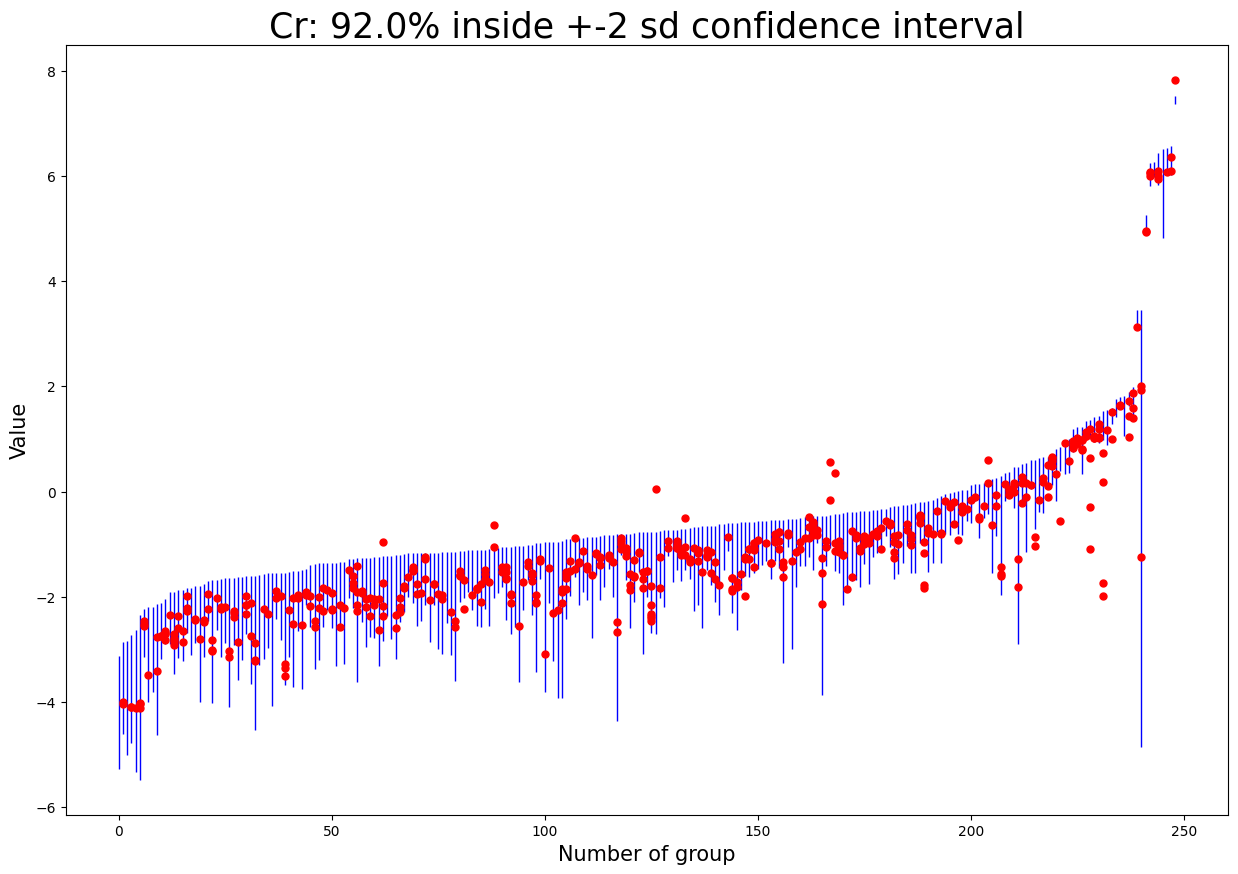

In [75]:
element = 2
percentage_correct = np.round(100*(np.array(sd_res_list).mean(0))[0,element], 1)

sorted_upper_bound_df = upper_bound_df.sort_values(upper_bound_df.columns[element])
sorted_upper_bound_df.reset_index(drop=True, inplace=True)
sorted_lower_bound_df = lower_bound_df.iloc[upper_bound_df.sort_values(upper_bound_df.columns[element]).index,:]
sorted_lower_bound_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_lower_bound_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_lower_bound_df.iloc[sample_id, element], 
                  ymax=sorted_upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
    
for row in range(outputs_df.shape[0]):
    new_index = sorted_upper_bound_df[sorted_upper_bound_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xlabel('Number of group',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside +-2 sd confidence interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
#plt.savefig('../figures/confidence_intervals_'+str(outputs_df.columns[element+1]))

### Visualisations of min-max intervals

In [76]:
# fig, ax = plt.subplots(2,4, figsize=(10,5))
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
#                   ymax=min_max_df.iloc[sample_id, element+1], 
#                   color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

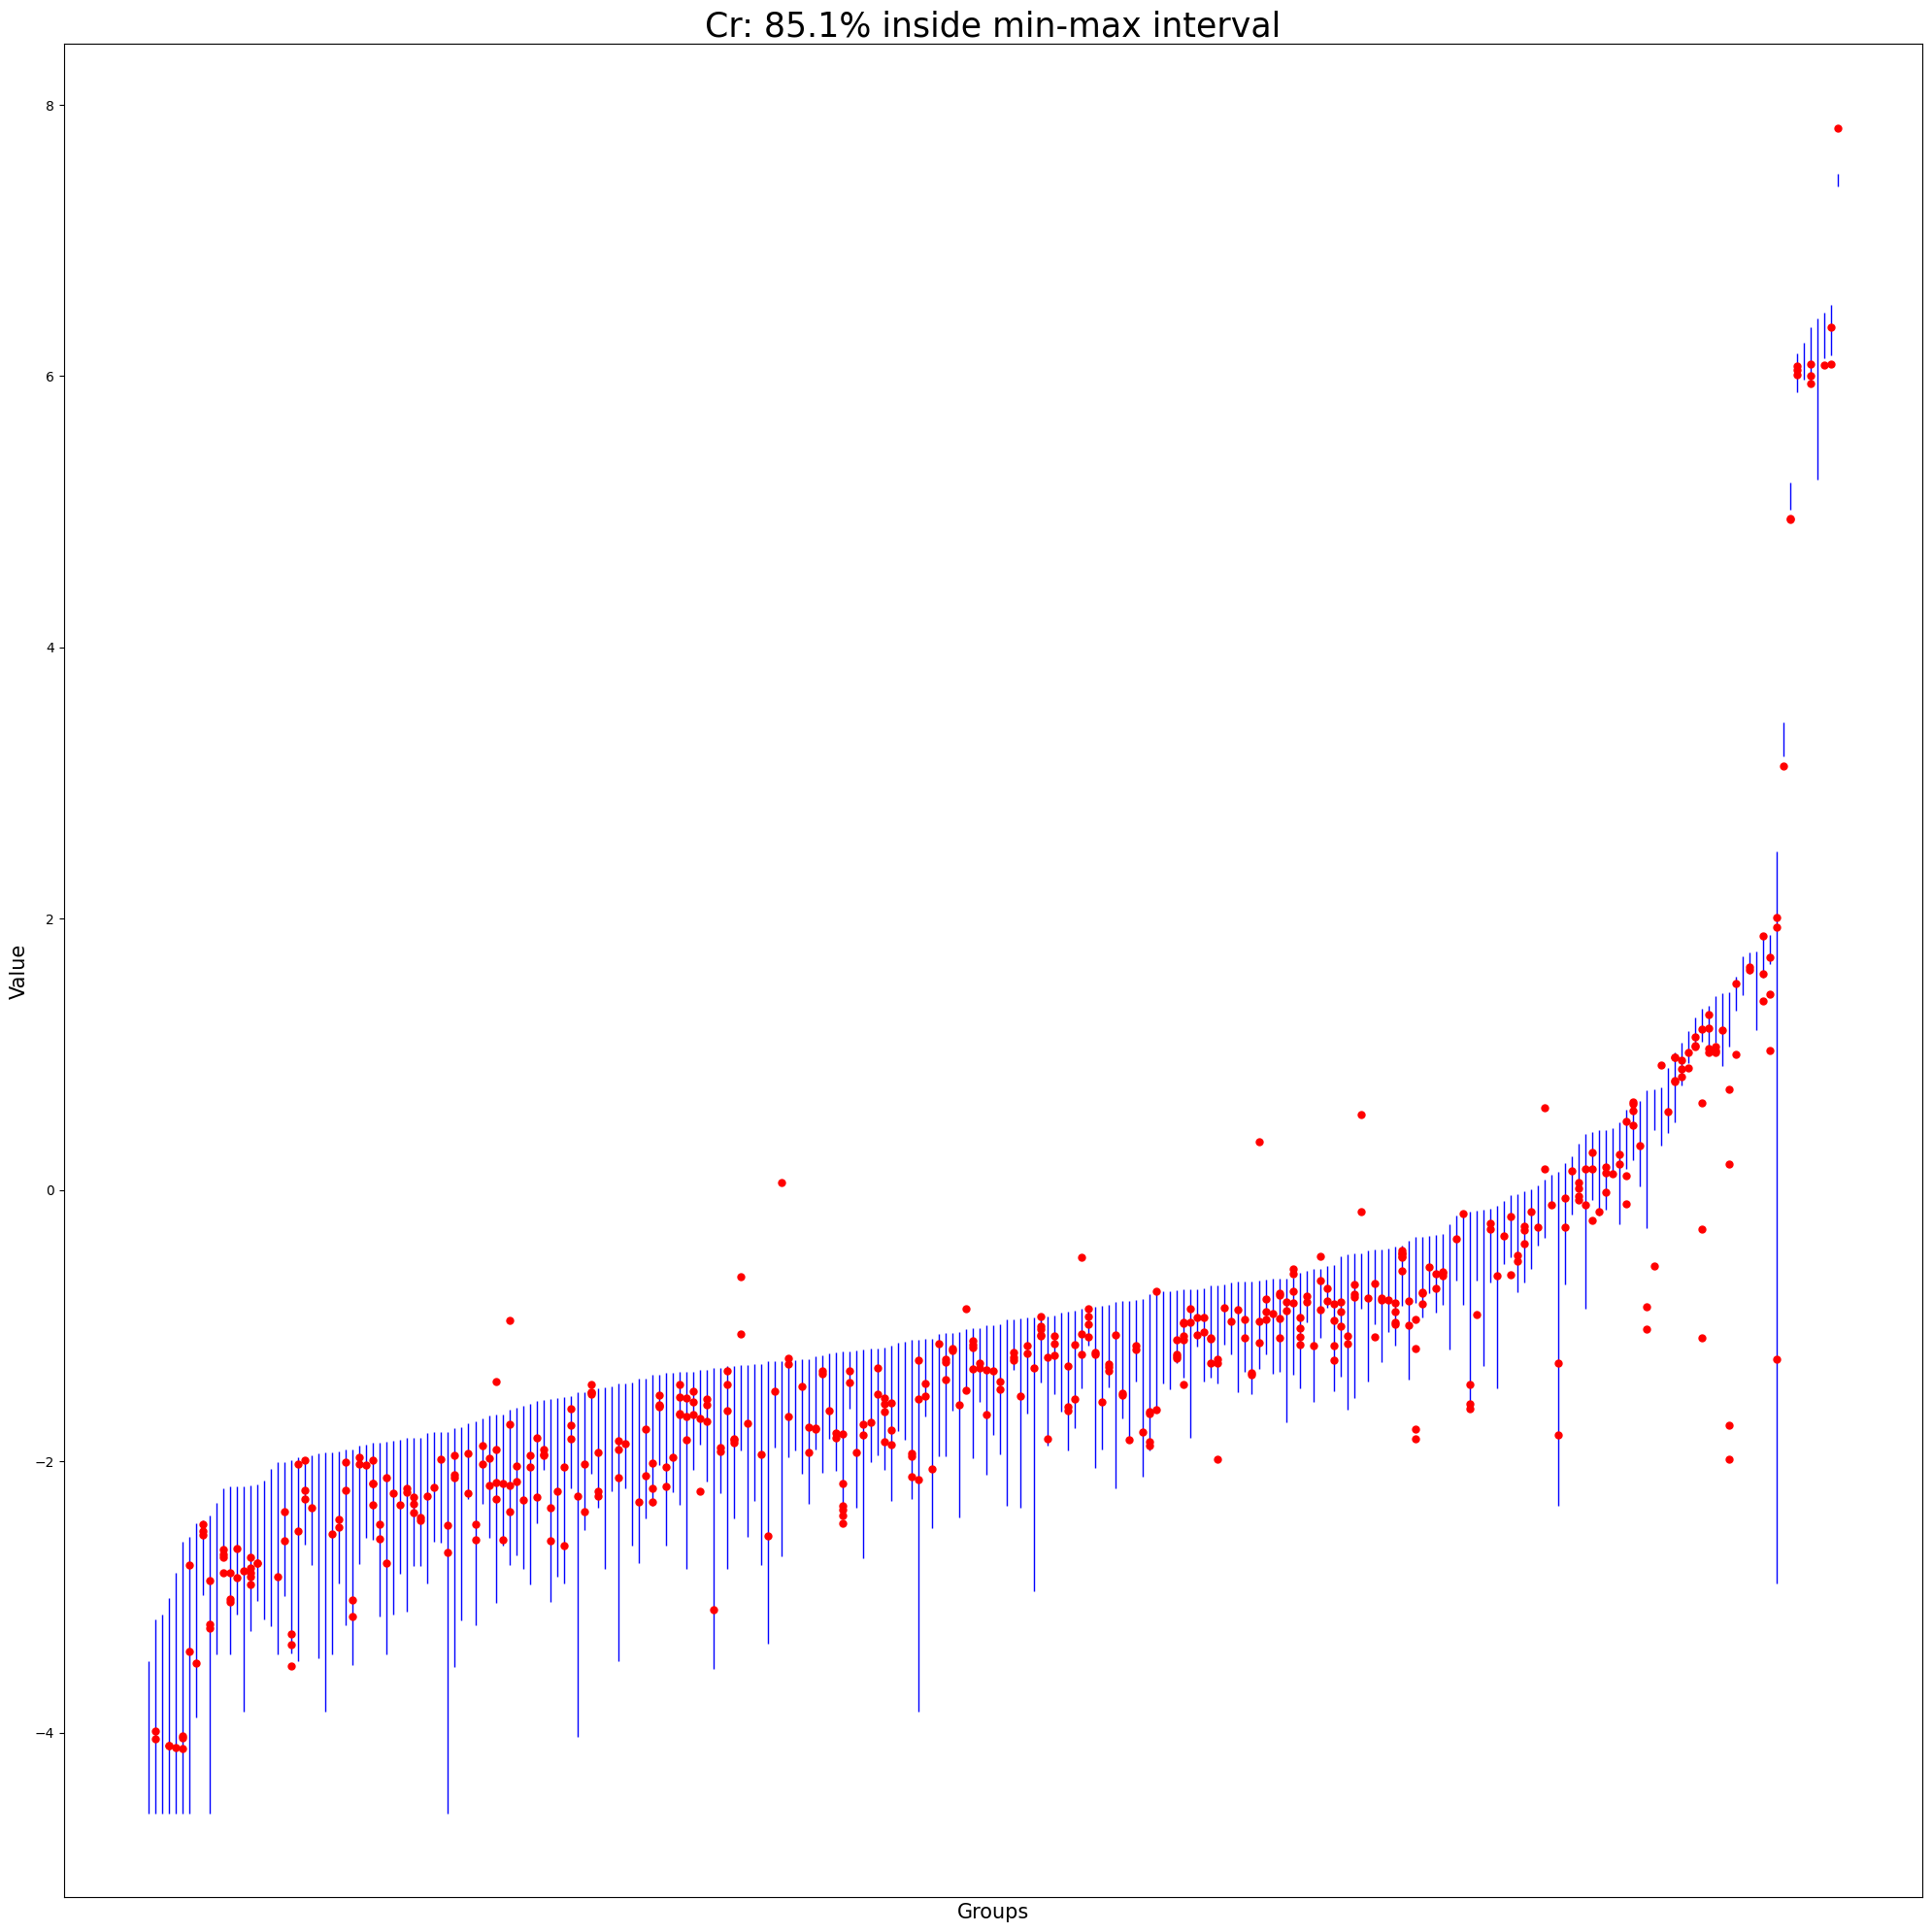

In [77]:
element = 2
percentage_correct = np.round(100*(np.array(min_max_res_list).mean(0))[0,element], 1)

sorted_min_max_df = min_max_df.sort_values(min_max_df.columns[element+1])
sorted_min_max_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_min_max_df.iloc[sample_id, element+len(elements_to_keep)+1], 
                  ymax=sorted_min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

for row in range(outputs_df.shape[0]):
    new_index = sorted_min_max_df[sorted_min_max_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xticks([], [])
plt.xlabel('Groups',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside min-max interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
plt.tight_layout()

#plt.savefig('../figures/min_max_intervals_'+str(outputs_df.columns[element+1]))

## Interpretability